In [1]:
import datetime
import glob

import cmocean.cm as cmo
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import xarray as xr

from scipy import interpolate

import parcels

In [2]:
animals_to_exclude = ["CC17", "CC29", "CC30"]
files = sorted([file for file in glob.glob("Loggerhead_Simulation_C*.parquet") if not any(animal in file for animal in animals_to_exclude)])

CC13 @ 12C: Mean drift time: 15.48 days, Max drift time: 21 days, Min drift time: 10 days
CC14 @ 12C: Mean drift time: 16.89 days, Max drift time: 21 days, Min drift time: 11 days
CC15 @ 12C: Mean drift time: 25.68 days, Max drift time: 34 days, Min drift time: 21 days
CC16 @ 12C: Mean drift time: 15.84 days, Max drift time: 19 days, Min drift time: 13 days
CC18 @ 12C: Mean drift time: 38.34 days, Max drift time: 59 days, Min drift time: 28 days
CC19 @ 12C: Mean drift time: 34.66 days, Max drift time: 60 days, Min drift time: 28 days
CC20 @ 12C: Mean drift time: 45.88 days, Max drift time: 72 days, Min drift time: 38 days
CC21 @ 12C: Mean drift time: 65.97 days, Max drift time: 73 days, Min drift time: 40 days
CC22 @ 12C: Mean drift time: 59.75 days, Max drift time: 74 days, Min drift time: 40 days
CC23 @ 12C: Mean drift time: 65.21 days, Max drift time: 150 days, Min drift time: 48 days
CC24 @ 12C: Mean drift time: 141.61 days, Max drift time: 155 days, Min drift time: 85 days
CC25 @ 

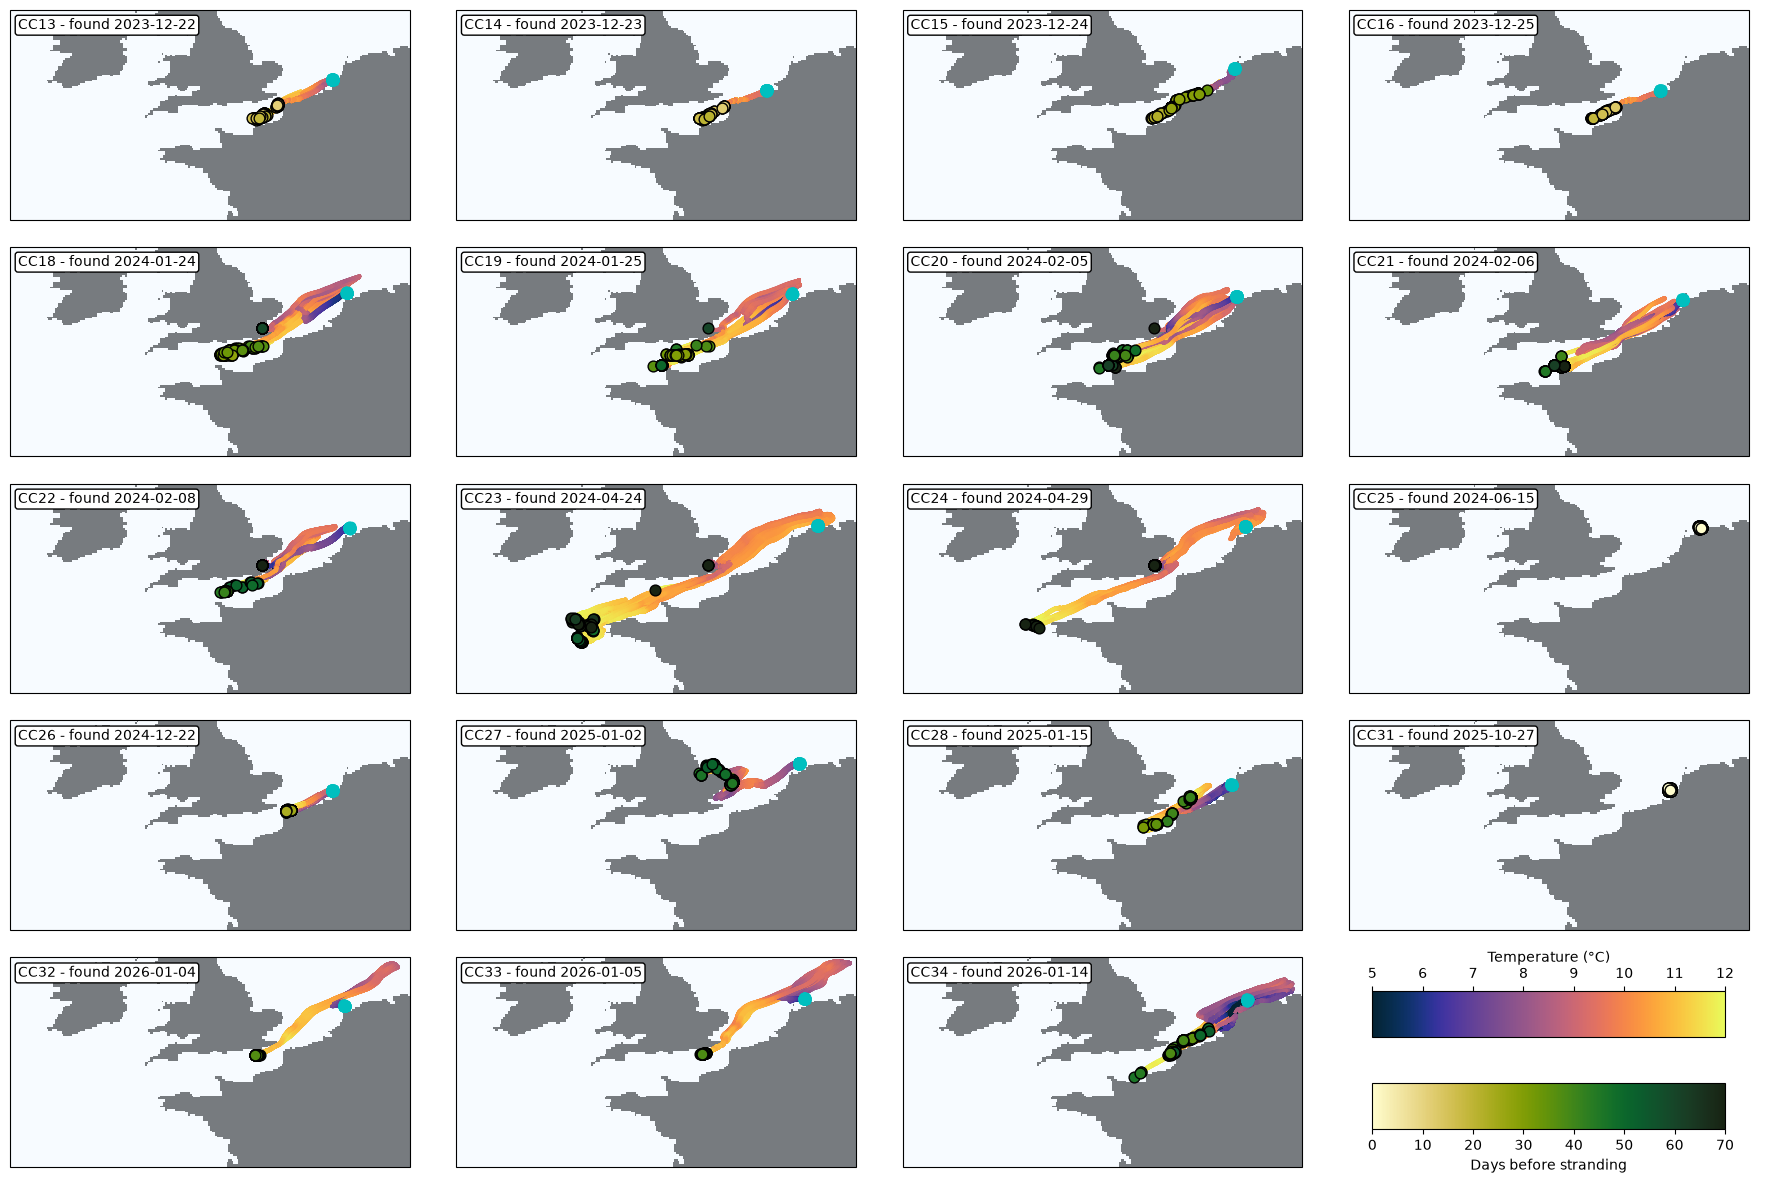

CC13 @ 14C: Mean drift time: 29.92 days, Max drift time: 31 days, Min drift time: 27 days
CC14 @ 14C: Mean drift time: 31.67 days, Max drift time: 50 days, Min drift time: 30 days
CC15 @ 14C: Mean drift time: 35.63 days, Max drift time: 42 days, Min drift time: 33 days
CC16 @ 14C: Mean drift time: 33.50 days, Max drift time: 52 days, Min drift time: 32 days
CC18 @ 14C: Mean drift time: 65.34 days, Max drift time: 76 days, Min drift time: 51 days
CC19 @ 14C: Mean drift time: 64.95 days, Max drift time: 77 days, Min drift time: 51 days
CC20 @ 14C: Mean drift time: 79.02 days, Max drift time: 88 days, Min drift time: 64 days
CC21 @ 14C: Mean drift time: 77.59 days, Max drift time: 86 days, Min drift time: 71 days
CC22 @ 14C: Mean drift time: 87.42 days, Max drift time: 91 days, Min drift time: 69 days
CC23 @ 14C: Mean drift time: 119.79 days, Max drift time: 167 days, Min drift time: 96 days
CC24 @ 14C: Mean drift time: 166.50 days, Max drift time: 172 days, Min drift time: 142 days
CC25 

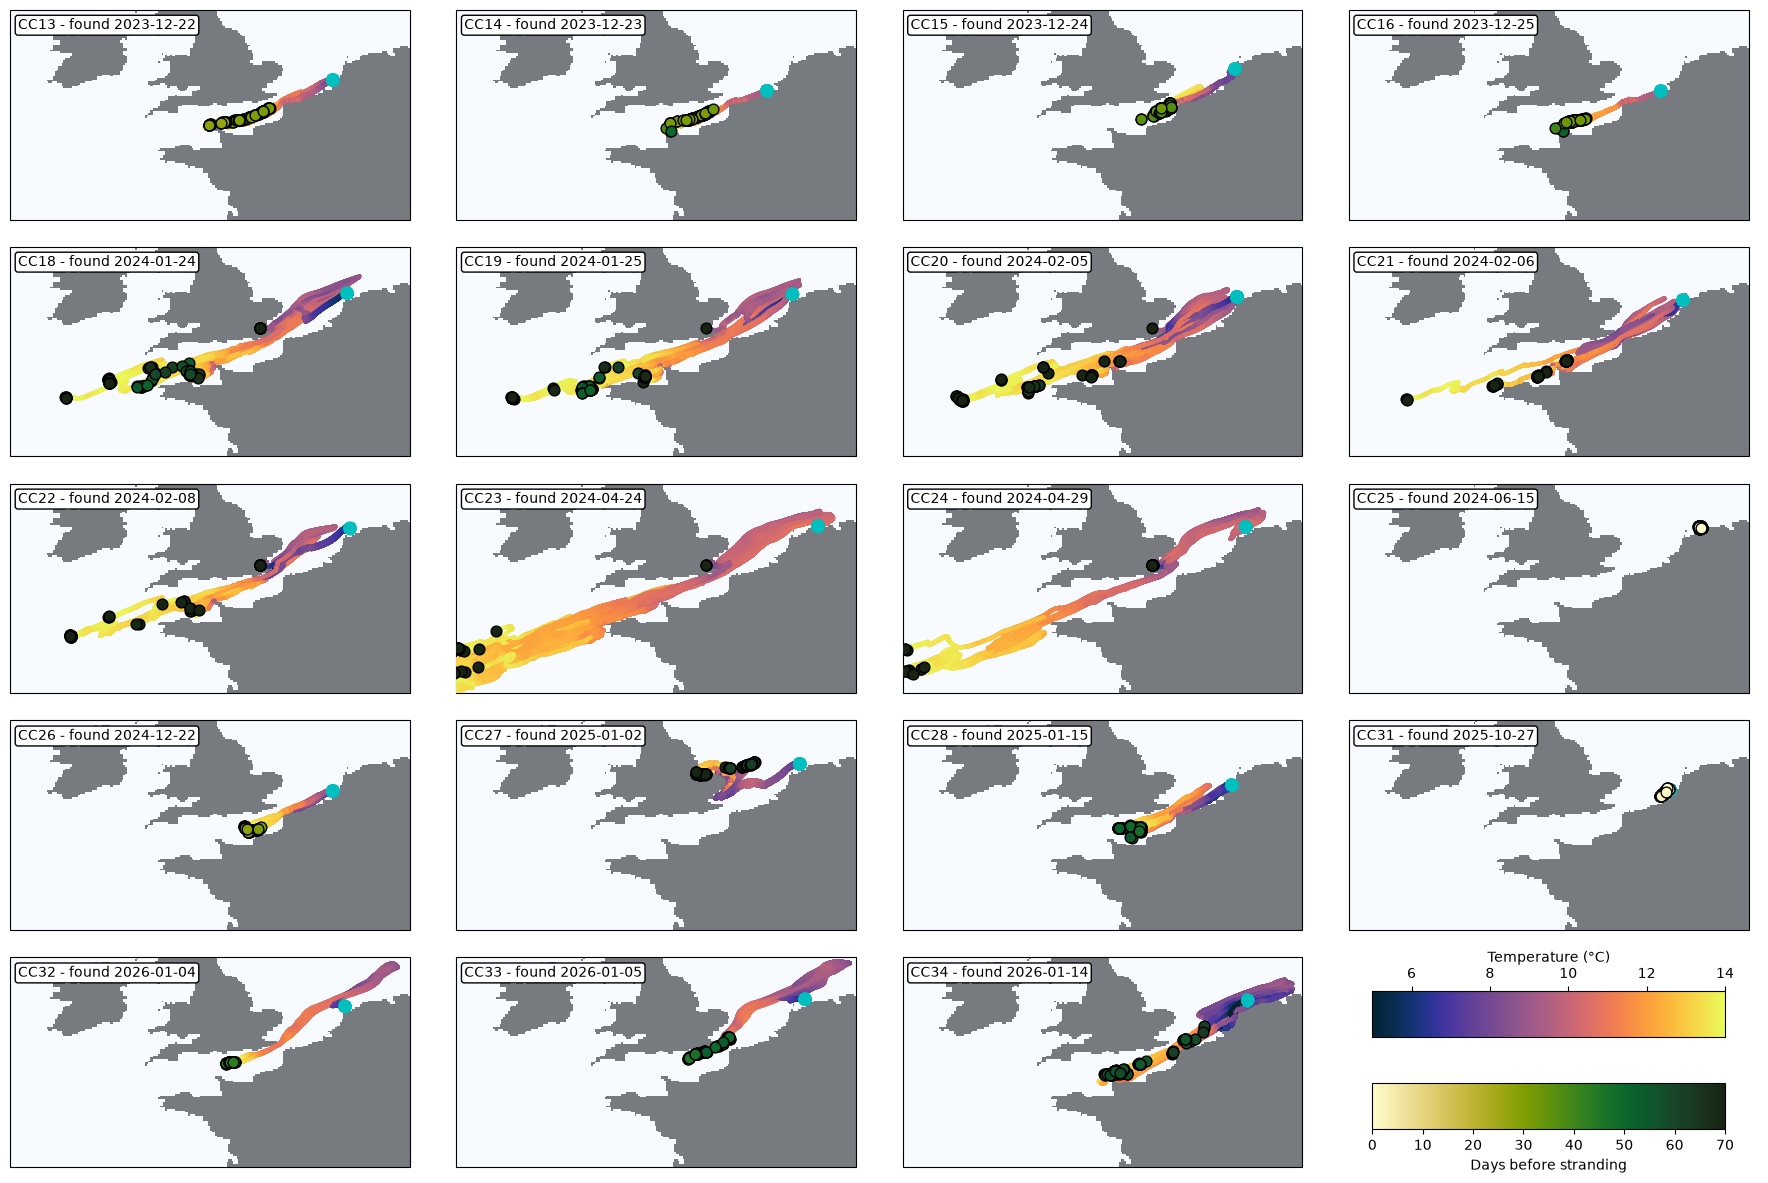

CC13 @ 16C: Mean drift time: 52.00 days, Max drift time: 58 days, Min drift time: 47 days
CC14 @ 16C: Mean drift time: 51.63 days, Max drift time: 61 days, Min drift time: 48 days
CC15 @ 16C: Mean drift time: 53.52 days, Max drift time: 64 days, Min drift time: 50 days
CC16 @ 16C: Mean drift time: 56.04 days, Max drift time: 63 days, Min drift time: 50 days
CC18 @ 16C: Mean drift time: 88.55 days, Max drift time: 92 days, Min drift time: 83 days
CC19 @ 16C: Mean drift time: 86.97 days, Max drift time: 93 days, Min drift time: 84 days
CC20 @ 16C: Mean drift time: 98.85 days, Max drift time: 104 days, Min drift time: 93 days
CC21 @ 16C: Mean drift time: 95.07 days, Max drift time: 101 days, Min drift time: 94 days
CC22 @ 16C: Mean drift time: 105.10 days, Max drift time: 107 days, Min drift time: 101 days
CC23 @ 16C: Mean drift time: 153.37 days, Max drift time: 180 days, Min drift time: 136 days
CC24 @ 16C: Mean drift time: 179.35 days, Max drift time: 180 days, Min drift time: 169 days

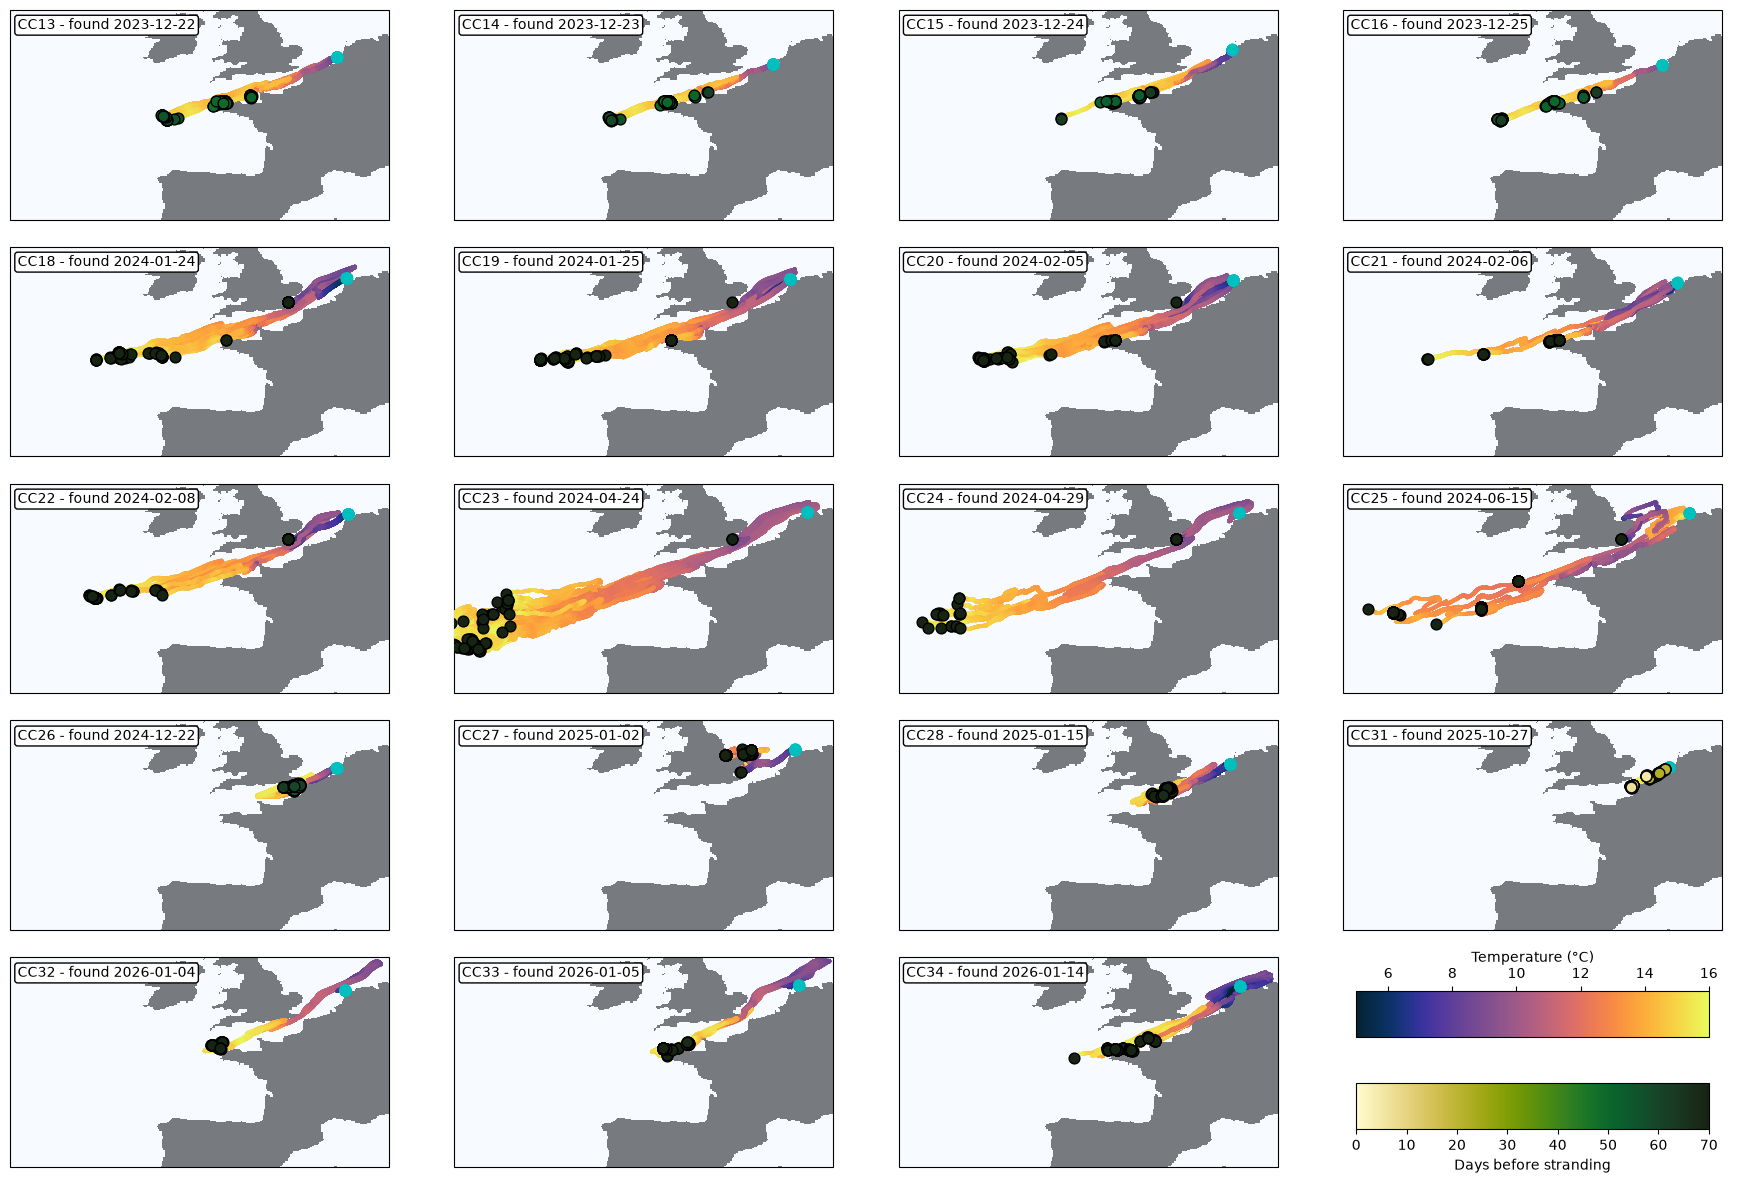

In [3]:
DIR = "/project/parcels/Data/TMP"

ds_fld = xr.open_dataset(f"{DIR}/copernicus_physics.nc")
land_mask_condition = (ds_fld.U.data[0, 0, :, :] == 0) & \
                      (ds_fld.V.data[0, 0, :, :] == 0)
landmask = np.ma.masked_where(land_mask_condition, land_mask_condition)
lon, lat = ds_fld.lon, ds_fld.lat
lon_centers = lon[1:] - np.diff(lon) / 2
lat_centers = lat[1:] - np.diff(lat) / 2
x, y = np.meshgrid(lon_centers, lat_centers)

fl = interpolate.RectBivariateSpline(lat, lon, landmask.mask, kx=1, ky=1)
lmask = (fl(y[:, 0], x[0, :]) > 0.95).astype(int)
ds_fld.close()

for mintemp in [12, 14, 16]:
    fig, axes = plt.subplots(5, 4, figsize=(18, 12), subplot_kw={'projection': ccrs.PlateCarree()})

    xmin, xmax = np.inf, -np.inf
    ymin, ymax = np.inf, -np.inf

    for i, file in enumerate(files):
        df = parcels.read_particlefile(file)
        df = df.with_columns(
            pl.col("temperature").replace(0, np.nan).alias("temperature")
        )
        xmin = min(xmin, df["x"].min())
        xmax = max(xmax, df["x"].max())
        ymin = min(ymin, df["y"].min())
        ymax = max(ymax, df["y"].max())

        ax = axes[i // 4, i % 4]
        ax.set_facecolor('aliceblue')

        ax.pcolormesh(x, y, lmask, cmap='Greys', alpha=0.5, zorder=0)

        drifttimes = np.zeros((100, 1), dtype=int)
        for traj in df.partition_by("particle_id", maintain_order=True):

            temp = np.asarray(traj["temperature"])
            warm_idx = np.flatnonzero(temp > mintemp)

            if warm_idx.size == 0:
                frozen = len(temp) - 1
            elif warm_idx.size == 1:
                frozen = int(warm_idx[0])
            else:
                frozen = int(warm_idx[1])
            drifttime = (traj["t"][0] - traj["t"][frozen]).days
            drifttimes[traj["particle_id"][0]] = drifttime

            scat = ax.scatter(
                traj["x"][:frozen],
                traj["y"][:frozen],
                c=traj["temperature"][:frozen],
                s=3,
                zorder=3,
                cmap=cmo.thermal,
                vmin=5,
                vmax=mintemp,
            )
            ax.plot(traj["x"][0], traj["y"][0], "co", zorder=4)
            age = ax.scatter(
                traj["x"][frozen],
                traj["y"][frozen],
                c=drifttime,
                s=60,
                zorder=5,
                cmap=cmo.speed,
                vmin=0,
                vmax=70,
                edgecolor='k',
            )

        if mintemp == 16:
            ax.set_xlim([-20, 8])
            ax.set_ylim([40, 55.5])
        else:
            ax.set_xlim([-12, 8])
            ax.set_ylim([45, 55.5])
        ID = file.split('_')[-1].split('.')[0]
        beach_date = df['t'].max().strftime('%Y-%m-%d')
        ax.text(
            0.02, 0.96, f"{ID} - found {beach_date}",
            transform=ax.transAxes,
            ha="left", va="top", fontsize=10, zorder=6,
            bbox=dict(facecolor="white", edgecolor="black", linewidth=1.0, boxstyle="round,pad=0.2")
        )

        print(f"{ID} @ {mintemp}C: Mean drift time: {drifttimes.mean():.2f} days, Max drift time: {drifttimes.max()} days, Min drift time: {drifttimes.min()} days")

    # print(f"Overall bounds: x: [{xmin}, {xmax}], y: [{ymin}, {ymax}]")
    axes[-1, -1].axis("off")

    cax_top = axes[-1, -1].inset_axes([0.08, 0.62, 0.84, 0.22])
    cax_bottom = axes[-1, -1].inset_axes([0.08, 0.18, 0.84, 0.22])

    cbar_temp = fig.colorbar(scat, cax=cax_top, orientation="horizontal")
    cbar_temp.set_label("Temperature (°C)")
    cbar_temp.ax.xaxis.set_label_position("top")
    cbar_temp.ax.xaxis.set_ticks_position("top")  # optional: move ticks to top too

    cbar_age = fig.colorbar(age, cax=cax_bottom, orientation="horizontal")
    cbar_age.set_label("Days before stranding")

    plt.tight_layout()
    plt.savefig(f"loggerhead_combined_plot_{mintemp}C.png", dpi=300, bbox_inches='tight')
    plt.show()